# Lofted Surface Voronoi Generation

This notebook builds a lofted surface from 8 circles defined by radii in `data/lofted_surface_inputs.json`. Each circle is created on the `XY` plane around the origin and then translated along `Z` in fixed `12` unit increments: `0, 12, 24, ...`.

The loft is sliced by the `YZ` plane through the origin, one side is kept, a padded bounding box is filled with random points from `data/voronoi_points_inputs.json`, a bounded 3D Voronoi diagram is generated, and the cells are intersected with the kept half of the loft. Any later non-uniform scaling uses the center of the initial loft bounding box as its pivot, scales only in `X` and `Y`, and keeps `Z` unchanged.

All intersection curves that hit the kept shape are retained. Closed curves stay closed, and open curves are closed by connecting their endpoints with one straight segment. Only cells with no intersection at all are discarded. The final output is shown as a shaded static render so it remains visible even when notebook widget rendering is unreliable.

In [1]:
import colorsys
import json
import tempfile
from dataclasses import replace
from pathlib import Path
from uuid import uuid4

import ipywidgets as widgets
import numpy as np
import pyvista as pv
from IPython.display import Image, Markdown, display

from compass_web.lofted_surface_voronoi import (
    _build_staged_offset_lofts,
    _fan_surface_from_center,
    _fit_plane,
    _loft_between_polylines,
    _merge_meshes,
    analyze_and_generate_surfaces,
    build_analysis_output_meshes,
    build_bounded_voronoi_cells,
    build_lofted_surface,
    build_mesh_printability_report,
    build_polyline_mesh,
    clean_meshes_without_naked_edges,
    clip_surface_in_half,
    close_mesh_boundaries,
    count_connected_regions,
    export_mesh_to_stl,
    extract_naked_edge_loops,
    extract_surface_mesh,
    intersect_cells_with_surface,
    load_generation_config,
    load_voronoi_point_config,
    _fix_mesh_winding,
    align_loops_and_loft,
    orient_normals_outward,
    split_and_offset_plane_faces,
    pad_bounds,
    random_points_in_bounds,
    rebuild_polylines_from_discontinuities,
    resolve_non_manifold_faces,
    scale_points_in_xy,
    scale_polydata_in_xy,
    unify_mesh_normals,
)

pv.set_plot_theme("document")

MAX_MODEL_SPAN = 150.0
MIN_RADIUS = 5.0
MAX_RADIUS = 70.0
MAX_Z_INCREMENT = MAX_MODEL_SPAN / 7.0
SMALL_CELL_EXTRUSION_FACTOR = 0.1

surface_config_path = Path("data/lofted_surface_inputs.json")
point_config_path = Path("data/voronoi_points_inputs.json")
surface_config = load_generation_config(surface_config_path)
point_config = load_voronoi_point_config(point_config_path)


def make_float_control(
    *,
    value: float,
    min_value: float,
    max_value: float,
    step: float,
    description: str,
    readout_format: str,
    slider_width: str = "440px",
    input_width: str = "100px",
) -> tuple[widgets.HBox, widgets.FloatSlider, widgets.BoundedFloatText]:
    slider = widgets.FloatSlider(
        value=value,
        min=min_value,
        max=max_value,
        step=step,
        description=description,
        continuous_update=False,
        readout=False,
        layout=widgets.Layout(width=slider_width),
        style={"description_width": "70px"},
    )
    # The bounded text box gives a direct click-and-type way to enter exact values.
    text = widgets.BoundedFloatText(
        value=value,
        min=min_value,
        max=max_value,
        step=step,
        layout=widgets.Layout(width=input_width),
    )
    widgets.jslink((slider, "value"), (text, "value"))
    row = widgets.HBox([slider, text])
    return row, slider, text


def make_int_control(
    *,
    value: int,
    min_value: int,
    max_value: int,
    step: int,
    description: str,
    slider_width: str = "440px",
    input_width: str = "100px",
) -> tuple[widgets.HBox, widgets.IntSlider, widgets.BoundedIntText]:
    slider = widgets.IntSlider(
        value=value,
        min=min_value,
        max=max_value,
        step=step,
        description=description,
        continuous_update=False,
        readout=False,
        layout=widgets.Layout(width=slider_width),
        style={"description_width": "70px"},
    )
    text = widgets.BoundedIntText(
        value=value,
        min=min_value,
        max=max_value,
        step=step,
        layout=widgets.Layout(width=input_width),
    )
    widgets.jslink((slider, "value"), (text, "value"))
    row = widgets.HBox([slider, text])
    return row, slider, text


radius_controls = [
    make_float_control(
        value=float(radius),
        min_value=MIN_RADIUS,
        max_value=MAX_RADIUS,
        step=0.001,
        description=f"R{i + 1}",
        readout_format=".3f",
    )
    for i, radius in enumerate(surface_config.radii)
]
radius_rows = [row for row, _, _ in radius_controls]
radius_sliders = [slider for _, slider, _ in radius_controls]

spacing_row, spacing_slider, _ = make_float_control(
    value=float(surface_config.z_increment),
    min_value=4.0,
    max_value=MAX_Z_INCREMENT,
    step=0.01,
    description="Spacing",
    readout_format=".2f",
)
point_count_row, point_count_slider, _ = make_int_control(
    value=int(point_config.seed_count),
    min_value=2,
    max_value=300,
    step=1,
    description="Points",
)
seed_row, seed_slider, _ = make_int_control(
    value=int(point_config.random_seed),
    min_value=0,
    max_value=9999,
    step=1,
    description="Seed",
)
extrusion_row, extrusion_multiplier_slider, _ = make_float_control(
    value=-0.2,
    min_value=-3.0,
    max_value=3.0,
    step=0.05,
    description="Extrude",
    readout_format=".2f",
)
scale_x_row, scale_x_slider, _ = make_float_control(
    value=0.5,
    min_value=0.1,
    max_value=1.5,
    step=0.01,
    description="Scale X",
    readout_format=".2f",
)
scale_y_row, scale_y_slider, _ = make_float_control(
    value=0.5,
    min_value=0.1,
    max_value=1.5,
    step=0.01,
    description="Scale Y",
    readout_format=".2f",
)


def validate_geometry_limits(radii: tuple[float, ...], z_increment: float) -> tuple[float, float]:
    max_width = 2.0 * max(radii)
    max_height = z_increment * (len(radii) - 1)
    if max_width > MAX_MODEL_SPAN + 1e-9:
        raise ValueError(
            f"The widest circle would produce {max_width:.2f} units in width, which is above the {MAX_MODEL_SPAN:.0f} unit limit."
        )
    if max_height > MAX_MODEL_SPAN + 1e-9:
        raise ValueError(
            f"The stacked circles would span {max_height:.2f} units in Z, which is above the {MAX_MODEL_SPAN:.0f} unit limit."
        )
    return max_width, max_height


def get_active_surface_config():
    radii = tuple(float(slider.value) for slider in radius_sliders)
    z_increment = float(spacing_slider.value)
    validate_geometry_limits(radii, z_increment)
    z_levels = tuple(index * z_increment for index in range(len(radii)))
    return replace(surface_config, radii=radii, z_increment=z_increment, z_levels=z_levels)


def get_active_point_config():
    return replace(
        point_config,
        seed_count=int(point_count_slider.value),
        random_seed=int(seed_slider.value),
    )


def get_extrusion_multiplier() -> float:
    return float(extrusion_multiplier_slider.value)


def get_planar_scales() -> tuple[float, float]:
    return float(scale_x_slider.value), float(scale_y_slider.value)


# Geometry operations that are reused across notebook stages live in the module so the workflow cells stay shorter.


def polyline_point_keys(polyline: np.ndarray, tolerance: float) -> set[tuple[int, int, int]]:
    unique_points = polyline[:-1] if len(polyline) > 1 else polyline
    return {
        tuple(np.round(np.asarray(point, dtype=float) / tolerance).astype(int).tolist())
        for point in unique_points
    }


def filter_isolated_polylines(
    polylines: list[np.ndarray],
    tolerance: float,
) -> tuple[list[np.ndarray], list[int], list[int]]:
    if not polylines:
        return [], [], []
    point_key_sets = [polyline_point_keys(polyline, tolerance=tolerance) for polyline in polylines]
    kept_indices: list[int] = []
    discarded_indices: list[int] = []
    for index, point_keys in enumerate(point_key_sets):
        has_neighbor = any(
            index != other_index and len(point_keys.intersection(other_point_keys)) > 0
            for other_index, other_point_keys in enumerate(point_key_sets)
        )
        if has_neighbor:
            kept_indices.append(index)
        else:
            discarded_indices.append(index)
    return [polylines[index] for index in kept_indices], kept_indices, discarded_indices


display(
    Markdown(
        "### Geometry Controls\n\n"
        "These controls override the JSON defaults for this notebook run only. "
        "Every slider also has a bounded number field on the right so you can click and type exact values.\n\n"
        f"Design guardrails: total width must stay at or below {MAX_MODEL_SPAN:.0f} units and total Z height must also stay at or below {MAX_MODEL_SPAN:.0f} units. "
        "Width here is `2 * max(radius)`, and height is `7 * spacing` because the loft uses 8 circles. "
        "The `Extrude` control can be positive or negative, and the extra `Scale X` and `Scale Y` controls drive the non-uniform deformation applied later around the center of the initial loft bounding box while keeping `Z` unchanged."
    )
)
configs_dir = Path("configs")
configs_dir.mkdir(exist_ok=True)


def _list_saved_configs() -> list[str]:
    return sorted(
        [f.stem for f in configs_dir.glob("*.json")],
        reverse=True,
    )


def _save_current_config(_: object = None) -> None:
    from datetime import datetime
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    cfg_data = {
        "radii": [float(s.value) for s in radius_sliders],
        "z_increment": float(spacing_slider.value),
        "seed_count": int(point_count_slider.value),
        "random_seed": int(seed_slider.value),
        "extrusion_multiplier": float(extrusion_multiplier_slider.value),
        "scale_x": float(scale_x_slider.value),
        "scale_y": float(scale_y_slider.value),
    }
    existing = _list_saved_configs()
    for name in existing:
        existing_data = json.loads((configs_dir / f"{name}.json").read_text())
        if existing_data == cfg_data:
            config_status.value = f"<b>Config identical to {name}, not saved.</b>"
            return
    path = configs_dir / f"{ts}.json"
    path.write_text(json.dumps(cfg_data, indent=2))
    config_dropdown.options = ["(current)"] + _list_saved_configs()
    config_status.value = f"<b>Saved: {ts}</b>"


def _load_selected_config(_: object = None) -> None:
    name = config_dropdown.value
    if name == "(current)":
        return
    cfg_data = json.loads((configs_dir / f"{name}.json").read_text())
    for i, val in enumerate(cfg_data["radii"]):
        if i < len(radius_sliders):
            radius_sliders[i].value = val
    spacing_slider.value = cfg_data["z_increment"]
    point_count_slider.value = cfg_data["seed_count"]
    seed_slider.value = cfg_data["random_seed"]
    extrusion_multiplier_slider.value = cfg_data["extrusion_multiplier"]
    scale_x_slider.value = cfg_data["scale_x"]
    scale_y_slider.value = cfg_data["scale_y"]
    config_status.value = f"<b>Loaded: {name}</b>"


config_dropdown = widgets.Dropdown(
    options=["(current)"] + _list_saved_configs(),
    value="(current)",
    description="Config:",
    layout=widgets.Layout(width="300px"),
)
config_save_btn = widgets.Button(description="Save config", button_style="info")
config_load_btn = widgets.Button(description="Load config", button_style="warning")
config_status = widgets.HTML()
config_save_btn.on_click(_save_current_config)
config_load_btn.on_click(_load_selected_config)

display(
    widgets.VBox(
        [
            *radius_rows,
            spacing_row,
            point_count_row,
            seed_row,
            extrusion_row,
            scale_x_row,
            scale_y_row,
            widgets.HBox([config_dropdown, config_load_btn, config_save_btn]),
            config_status,
        ]
    )
)
(surface_config, point_config)


### Geometry Controls

These controls override the JSON defaults for this notebook run only. Every slider also has a bounded number field on the right so you can click and type exact values.

Design guardrails: total width must stay at or below 150 units and total Z height must also stay at or below 150 units. Width here is `2 * max(radius)`, and height is `7 * spacing` because the loft uses 8 circles. The `Extrude` control can be positive or negative, and the extra `Scale X` and `Scale Y` controls drive the non-uniform deformation applied later around the center of the initial loft bounding box while keeping `Z` unchanged.

(LoftedVoronoiConfig(radii=(8.91, 10.446, 10.46, 17.66, 11.26, 19.299, 11.26, 14.46), z_levels=(0.0, 13.38, 26.76, 40.14, 53.52, 66.9, 80.28, 93.66000000000001), z_increment=13.38, circle_resolution=120, slice_normal=(1.0, 0.0, 0.0), slice_origin=(0.0, 0.0, 0.0), bbox_padding=4.0, line_tolerance=0.001),
 VoronoiPointConfig(seed_count=78, random_seed=12))

In [14]:
# Read the latest widget values once so every downstream cell works from the same inputs.
active_surface_config = get_active_surface_config()
active_point_config = get_active_point_config()
raw_extrusion_multiplier = get_extrusion_multiplier()
extrusion_multiplier = 5.0 * raw_extrusion_multiplier
scale_x, scale_y = get_planar_scales()

# The widest section controls the total width because all circles are centered on the origin.
current_width = 2.0 * max(active_surface_config.radii)
current_height = active_surface_config.z_levels[-1] - active_surface_config.z_levels[0]

# Build the full loft first, then clip it in half along the YZ plane.
full_surface = build_lofted_surface(active_surface_config)
full_loft_bounds = full_surface.bounds
initial_loft_bbox_center = np.array(
    [
        0.5 * (full_loft_bounds[0] + full_loft_bounds[1]),
        0.5 * (full_loft_bounds[2] + full_loft_bounds[3]),
        0.5 * (full_loft_bounds[4] + full_loft_bounds[5]),
    ],
    dtype=float,
)
half_surface = clip_surface_in_half(
    full_surface,
    normal=active_surface_config.slice_normal,
    origin=active_surface_config.slice_origin,
)

# A slightly larger box is used later so the Voronoi cells stay finite before intersection.
padded_bounds = pad_bounds(half_surface.bounds, active_surface_config.bbox_padding)

print(f"Radii: {list(active_surface_config.radii)}")
print(f"Z positions: {list(active_surface_config.z_levels)}")
print(f"Current width: {current_width:.2f} / {MAX_MODEL_SPAN:.0f}")
print(f"Current height: {current_height:.2f} / {MAX_MODEL_SPAN:.0f}")
print(f"Slice plane: YZ at x = {active_surface_config.slice_origin[0]}")
print(f"Voronoi seed points: {active_point_config.seed_count}")
print(f"Voronoi random seed: {active_point_config.random_seed}")
print(f"Extrusion slider value: {raw_extrusion_multiplier:.2f}")
print(f"Effective extrusion multiplier (x5): {extrusion_multiplier:.2f}")
print(f"Planar scaling (X, Y) with Z fixed: ({scale_x:.2f}, {scale_y:.2f})")
print(f"Scaling pivot: {initial_loft_bbox_center.tolist()}")
print(f"Full loft surface: {full_surface.n_points} points / {full_surface.n_cells} cells")
print(f"Kept half surface: {half_surface.n_points} points / {half_surface.n_cells} cells")
print(f"Padded bounds: {padded_bounds}")


Radii: [8.91, 13.904, 20.3, 25.46, 27.973, 24.125, 17.203, 13.346]
Z positions: [0.0, 15.320000000000002, 30.640000000000004, 45.96000000000001, 61.28000000000001, 76.60000000000001, 91.92000000000002, 107.24000000000001]
Current width: 55.95 / 150
Current height: 107.24 / 150
Slice plane: YZ at x = 0.0
Voronoi seed points: 110
Voronoi random seed: 783
Extrusion slider value: -0.20
Effective extrusion multiplier (x5): -1.00
Planar scaling (X, Y) with Z fixed: (0.50, 0.50)
Scaling pivot: [0.0, 0.0, 53.620000000000005]
Full loft surface: 960 points / 1680 cells
Kept half surface: 510 points / 868 cells
Padded bounds: (-4.0, 31.973, -31.973, 31.973, -4.0, 111.24000000000001)


In [15]:
# Fill the padded box with random points. These points are the seeds that define the Voronoi cells.
seed_points = random_points_in_bounds(
    bounds=padded_bounds,
    count=active_point_config.seed_count,
    seed=active_point_config.random_seed,
)

# Build finite Voronoi cells inside the padded box, then intersect them with the clipped loft.
voronoi_cells = build_bounded_voronoi_cells(seed_points, padded_bounds)
raw_closed_polylines = intersect_cells_with_surface(
    surface=half_surface,
    cells=voronoi_cells,
    tolerance=active_surface_config.line_tolerance,
)
closed_polylines, kept_polyline_indices, discarded_polyline_indices = filter_isolated_polylines(
    raw_closed_polylines,
    tolerance=active_surface_config.line_tolerance,
)
retained_intersection_polyline_count = len(closed_polylines)
polyline_snap_tolerance = max(20.0 * active_surface_config.line_tolerance, 0.02)
closed_polylines = rebuild_polylines_from_discontinuities(
    closed_polylines,
    tolerance=active_surface_config.line_tolerance,
    discontinuity_angle_degrees=176.0,
    neighbor_snap_tolerance=polyline_snap_tolerance,
)
polyline_mesh = build_polyline_mesh(closed_polylines)
discarded_polyline_mesh = build_polyline_mesh([raw_closed_polylines[index] for index in discarded_polyline_indices])

print(f"Random seed points: {len(seed_points)}")
print(f"Voronoi random seed: {active_point_config.random_seed}")
print(f"Bounded Voronoi cells: {len(voronoi_cells)}")
print(f"Raw surface intersection polylines: {len(raw_closed_polylines)}")
print(f"Surface intersection polylines kept after neighbor filter: {retained_intersection_polyline_count}")
print(f"Rebuilt line polylines used downstream: {len(closed_polylines)}")
print(f"Polyline snap tolerance used: {polyline_snap_tolerance:.4f}")
print(f"Discarded isolated polylines: {len(discarded_polyline_indices)}")
print(f"Polyline mesh lines: {polyline_mesh.n_lines}")


Random seed points: 110
Voronoi random seed: 783
Bounded Voronoi cells: 110
Raw surface intersection polylines: 61
Surface intersection polylines kept after neighbor filter: 60
Rebuilt line polylines used downstream: 60
Polyline snap tolerance used: 0.0200
Discarded isolated polylines: 1
Polyline mesh lines: 60


In [16]:
# Analyze each retained curve and generate the derived surface patches.
curve_result = analyze_and_generate_surfaces(
    closed_polylines,
    loft_bounds=full_surface.bounds,
    tolerance=active_surface_config.line_tolerance,
    extrusion_multiplier=extrusion_multiplier,
    small_cell_extrusion_factor=SMALL_CELL_EXTRUSION_FACTOR,
    extrusion_scale_origin=initial_loft_bbox_center,
    planar_scale_factors=(scale_x, scale_y),
    slice_plane_x=active_surface_config.slice_origin[0],
)
analysis_original_polylines = [analysis.original_polyline for analysis in curve_result.analyses]
analysis_followup_polylines = [analysis.followup_polyline for analysis in curve_result.analyses]
followup_polyline_mesh = build_polyline_mesh(list(curve_result.followup_polylines))
bbox_edge_meshes = [analysis.bbox_mesh.extract_all_edges() for analysis in curve_result.analyses]
circle_centers = np.array([analysis.circle_center for analysis in curve_result.analyses], dtype=float)
scaled_circle_centers = np.array([analysis.scaled_circle_center for analysis in curve_result.analyses], dtype=float)
extrusion_base_vectors = np.array([analysis.extrusion_base_vector for analysis in curve_result.analyses], dtype=float)
extrusion_base_lengths = np.linalg.norm(extrusion_base_vectors, axis=1) if len(curve_result.analyses) > 0 else np.zeros(0, dtype=float)
curve_lengths = np.array([analysis.curve_length for analysis in curve_result.analyses], dtype=float)
bbox_volumes = np.array([analysis.bbox_volume for analysis in curve_result.analyses], dtype=float)
ratios = np.array([analysis.ratio for analysis in curve_result.analyses], dtype=float)
sorted_indices = np.argsort(ratios)[::-1]
large_curve_count = sum(analysis.ratio >= curve_result.average_ratio for analysis in curve_result.analyses)
small_curve_count = len(curve_result.analyses) - large_curve_count
discontinuity_point_sets = [analysis.discontinuity_points for analysis in curve_result.analyses]
all_discontinuity_points = (
    np.vstack([points for points in discontinuity_point_sets if len(points) > 0])
    if any(len(points) > 0 for points in discontinuity_point_sets)
    else np.zeros((0, 3), dtype=float)
)
curve_colors = [
    "#%02x%02x%02x" % tuple(int(channel * 255) for channel in colorsys.hsv_to_rgb(index / len(curve_result.analyses), 0.7, 1.0))
    for index in range(len(curve_result.analyses))
] if curve_result.analyses else []
curve_label_points = np.array([
    analysis.followup_polyline[:-1].mean(axis=0) for analysis in curve_result.analyses
], dtype=float) if curve_result.analyses else np.zeros((0, 3), dtype=float)
curve_labels = [f"crv {index + 1}" for index in range(len(curve_result.analyses))]
analysis_output_result = build_analysis_output_meshes(
    curve_result.analyses,
    average_ratio=curve_result.average_ratio,
    loft_bounds=full_surface.bounds,
    tolerance=active_surface_config.line_tolerance,
    extrusion_multiplier=extrusion_multiplier,
    small_cell_extrusion_factor=SMALL_CELL_EXTRUSION_FACTOR,
    slice_plane_x=active_surface_config.slice_origin[0],
)
analysis_preview_output_meshes = list(analysis_output_result.preview_meshes)
analysis_output_meshes = list(analysis_output_result.output_meshes)
analysis_output_modes = list(analysis_output_result.output_modes)
removed_by_retained_volume_indices = list(analysis_output_result.removed_by_retained_volume_indices)

mesh_cleanup = clean_meshes_without_naked_edges(
    analysis_output_meshes,
    tolerance=active_surface_config.line_tolerance,
)
merge_ready_output_meshes = list(mesh_cleanup.kept_meshes)
merge_ready_output_surfaces = list(mesh_cleanup.kept_surface_meshes)
removed_output_mesh_indices = list(mesh_cleanup.removed_indices)
generated_surface = _merge_meshes(merge_ready_output_meshes) if merge_ready_output_meshes else half_surface
generated_bounds = generated_surface.bounds if generated_surface.n_points else half_surface.bounds
generated_target = generated_surface.center if generated_surface.n_points else half_surface.center

print(f"Analyzed curves: {len(curve_result.analyses)}")
print(f"Average volume/length ratio: {curve_result.average_ratio:.4f}")
print(f"Extrusion multiplier used: {extrusion_multiplier:.2f}")
print(f"Small-cell extrusion factor: {SMALL_CELL_EXTRUSION_FACTOR:.2f}")
print(f"Scaled-center extrusion pivot: {initial_loft_bbox_center.tolist()}")
print(f"Planar scaling used for center vectors (X, Y) with Z fixed: ({scale_x:.2f}, {scale_y:.2f})")
print(f"Curves classified as large: {large_curve_count}")
print(f"Curves classified as small: {small_curve_count}")
print(f"Generated surface faces after retained-volume filtering and naked-edge cleanup: {generated_surface.n_cells}")
print(f"Cells removed by retained-volume criterion: {len(removed_by_retained_volume_indices)}")
print(f"Cells kept for downstream merge: {len(merge_ready_output_meshes)}")
print(f"Cells removed because they have no naked edges: {len(removed_output_mesh_indices)}")
print(f"Large-curve loft faces: {sum(mesh.n_cells for mesh, mode in zip(analysis_output_meshes, analysis_output_modes, strict=True) if mode == 'large')}")
print(f"Small-curve fan faces after retained-volume criterion: {sum(mesh.n_cells for mesh, mode in zip(analysis_output_meshes, analysis_output_modes, strict=True) if mode == 'small')}")
if len(extrusion_base_lengths) > 0:
    print(
        f"Scaled-center vector lengths - min: {extrusion_base_lengths.min():.3f}, "
        f"max: {extrusion_base_lengths.max():.3f}, "
        f"mean: {extrusion_base_lengths.mean():.3f}"
    )
if curve_result.followup_polylines:
    print(
        f"Working polyline segments - min: {min(len(polyline) - 1 for polyline in curve_result.followup_polylines)}, "
        f"max: {max(len(polyline) - 1 for polyline in curve_result.followup_polylines)}, "
        f"mean: {np.mean([len(polyline) - 1 for polyline in curve_result.followup_polylines]):.1f}"
    )
else:
    print("Working polyline segments: no retained curves were generated.")
print(f"Discontinuity markers total: {len(all_discontinuity_points)}")

top_count = min(8, len(sorted_indices))
summary_rows = [
    (
        int(index),
        float(ratios[index]),
        float(bbox_volumes[index]),
        float(curve_lengths[index]),
    )
    for index in sorted_indices[:top_count]
]
summary_rows


Analyzed curves: 60
Average volume/length ratio: 6.3116
Extrusion multiplier used: -1.00
Small-cell extrusion factor: 0.10
Scaled-center extrusion pivot: [0.0, 0.0, 53.620000000000005]
Planar scaling used for center vectors (X, Y) with Z fixed: (0.50, 0.50)
Curves classified as large: 22
Curves classified as small: 38
Generated surface faces after retained-volume filtering and naked-edge cleanup: 2995
Cells removed by retained-volume criterion: 0
Cells kept for downstream merge: 60
Cells removed because they have no naked edges: 0
Large-curve loft faces: 2364
Small-curve fan faces after retained-volume criterion: 631
Scaled-center vector lengths - min: 4.493, max: 13.450, mean: 9.914
Working polyline segments - min: 3, max: 56, mean: 20.4
Discontinuity markers total: 1222


[(13, 34.62636221833189, 2399.052480197347, 69.28398845568711),
 (0, 32.65924219192341, 2022.9543962953633, 61.94125339490079),
 (26, 20.993934992689244, 1533.5517294539263, 73.04736963260855),
 (20, 17.828305211783025, 1036.3895819305026, 58.13169393384265),
 (2, 17.32162753964561, 1228.107546843395, 70.90023983211229),
 (47, 16.400322491931835, 1115.7608143176287, 68.03285818718071),
 (8, 15.715040086928312, 1112.552488506597, 70.79539615250567),
 (11, 15.413305103877443, 1010.1590318765354, 65.5381195057519)]

In [17]:
def distinct_colors(count: int) -> list[str]:
    if count <= 0:
        return []
    return [
        "#%02x%02x%02x" % tuple(int(channel * 255) for channel in colorsys.hsv_to_rgb(index / count, 0.7, 1.0))
        for index in range(count)
    ]


def camera_position_from_bounds(
    bounds: tuple[float, float, float, float, float, float],
    target: np.ndarray | list[float] | tuple[float, float, float],
) -> list[list[float]]:
    xmin, xmax, ymin, ymax, zmin, zmax = bounds
    max_span = max(xmax - xmin, ymax - ymin, zmax - zmin, 1.0)
    target_array = np.asarray(target, dtype=float)
    # This keeps a readable three-quarter view while allowing the fitted bounds to control the final framing.
    camera_position = target_array + np.array([1.05 * max_span, -1.45 * max_span, 0.78 * max_span], dtype=float)
    return [camera_position.tolist(), target_array.tolist(), [0.0, 0.0, 1.0]]


def merge_bounds(bounds_list: list[tuple[float, float, float, float, float, float]]) -> tuple[float, float, float, float, float, float]:
    if not bounds_list:
        raise ValueError("bounds_list must not be empty.")
    mins = np.array([[bounds[0], bounds[2], bounds[4]] for bounds in bounds_list], dtype=float)
    maxs = np.array([[bounds[1], bounds[3], bounds[5]] for bounds in bounds_list], dtype=float)
    min_corner = mins.min(axis=0)
    max_corner = maxs.max(axis=0)
    return (
        float(min_corner[0]),
        float(max_corner[0]),
        float(min_corner[1]),
        float(max_corner[1]),
        float(min_corner[2]),
        float(max_corner[2]),
    )


def bounds_from_points(points: np.ndarray) -> tuple[float, float, float, float, float, float] | None:
    if len(points) == 0:
        return None
    points_array = np.asarray(points, dtype=float)
    min_corner = points_array.min(axis=0)
    max_corner = points_array.max(axis=0)
    return (
        float(min_corner[0]),
        float(max_corner[0]),
        float(min_corner[1]),
        float(max_corner[1]),
        float(min_corner[2]),
        float(max_corner[2]),
    )


def padded_scene_bounds(
    bounds: tuple[float, float, float, float, float, float],
    padding_fraction: float = 0.22,
    min_padding: float = 1.0,
) -> tuple[float, float, float, float, float, float]:
    xmin, xmax, ymin, ymax, zmin, zmax = bounds
    spans = np.array([xmax - xmin, ymax - ymin, zmax - zmin], dtype=float)
    padding = np.maximum(spans * padding_fraction, min_padding)
    return (
        float(xmin - padding[0]),
        float(xmax + padding[0]),
        float(ymin - padding[1]),
        float(ymax + padding[1]),
        float(zmin - padding[2]),
        float(zmax + padding[2]),
    )


def center_from_bounds(bounds: tuple[float, float, float, float, float, float]) -> np.ndarray:
    return np.array(
        [
            0.5 * (bounds[0] + bounds[1]),
            0.5 * (bounds[2] + bounds[3]),
            0.5 * (bounds[4] + bounds[5]),
        ],
        dtype=float,
    )


def add_scene_content(
    plotter: pv.Plotter,
    *,
    meshes: list[tuple[pv.DataSet, dict[str, object]]] | None = None,
    line_meshes: list[tuple[pv.PolyData, dict[str, object]]] | None = None,
    point_sets: list[tuple[np.ndarray, dict[str, object]]] | None = None,
    label_sets: list[tuple[np.ndarray, list[str], dict[str, object]]] | None = None,
) -> None:
    for mesh, kwargs in meshes or []:
        if mesh.n_points == 0:
            continue
        plotter.add_mesh(mesh, **kwargs)

    for line_mesh, kwargs in line_meshes or []:
        if line_mesh.n_points == 0:
            continue
        plotter.add_mesh(line_mesh, render_lines_as_tubes=True, **kwargs)

    for points, kwargs in point_sets or []:
        if len(points) == 0:
            continue
        plotter.add_points(np.asarray(points, dtype=float), **kwargs)

    for points, labels, kwargs in label_sets or []:
        if len(points) == 0 or not labels:
            continue
        plotter.add_point_labels(np.asarray(points, dtype=float), labels, **kwargs)


def render_static_scene(
    *,
    title: str,
    bounds: tuple[float, float, float, float, float, float],
    target: np.ndarray | list[float] | tuple[float, float, float],
    meshes: list[tuple[pv.DataSet, dict[str, object]]] | None = None,
    line_meshes: list[tuple[pv.PolyData, dict[str, object]]] | None = None,
    point_sets: list[tuple[np.ndarray, dict[str, object]]] | None = None,
    label_sets: list[tuple[np.ndarray, list[str], dict[str, object]]] | None = None,
    fit_bounds: tuple[float, float, float, float, float, float] | None = None,
    fit_target: np.ndarray | list[float] | tuple[float, float, float] | None = None,
    zoom_factor: float = 1.1,
    window_size: tuple[int, int] = (1100, 820),
) -> bytes:
    plotter = pv.Plotter(off_screen=True, window_size=window_size)
    plotter.set_background("#1a1a2e")
    add_scene_content(
        plotter,
        meshes=meshes,
        line_meshes=line_meshes,
        point_sets=point_sets,
        label_sets=label_sets,
    )

    plotter.add_axes()
    camera_bounds = fit_bounds if fit_bounds is not None else bounds
    camera_target = np.asarray(fit_target if fit_target is not None else target, dtype=float)
    plotter.camera_position = camera_position_from_bounds(camera_bounds, camera_target)
    # Static images have no orbit controls, so a mild zoom helps the fitted scene occupy more of the screenshot.
    plotter.camera.zoom(zoom_factor)
    plotter.add_text(title, position="upper_left", font_size=12, color="white")

    image_path = Path(tempfile.gettempdir()) / f"{uuid4().hex}.png"
    try:
        plotter.screenshot(str(image_path))
        return image_path.read_bytes()
    finally:
        plotter.close()
        image_path.unlink(missing_ok=True)


def display_static_scene(**kwargs: object) -> None:
    display(Image(data=render_static_scene(**kwargs)))


def display_interactive_scene(
    *,
    title: str,
    bounds: tuple[float, float, float, float, float, float],
    target: np.ndarray | list[float] | tuple[float, float, float],
    meshes: list[tuple[pv.DataSet, dict[str, object]]] | None = None,
    line_meshes: list[tuple[pv.PolyData, dict[str, object]]] | None = None,
    point_sets: list[tuple[np.ndarray, dict[str, object]]] | None = None,
    label_sets: list[tuple[np.ndarray, list[str], dict[str, object]]] | None = None,
    fit_bounds: tuple[float, float, float, float, float, float] | None = None,
    fit_target: np.ndarray | list[float] | tuple[float, float, float] | None = None,
    zoom_factor: float = 1.0,
    window_size: tuple[int, int] = (1200, 900),
) -> None:
    # PyVista's notebook html/trame backends are not available in this environment,
    # so the interactive inspection opens in a native VTK window instead.
    plotter = pv.Plotter(notebook=False, window_size=window_size)
    plotter.set_background("#1a1a2e")
    add_scene_content(
        plotter,
        meshes=meshes,
        line_meshes=line_meshes,
        point_sets=point_sets,
        label_sets=label_sets,
    )
    plotter.add_axes()
    camera_bounds = fit_bounds if fit_bounds is not None else bounds
    camera_target = np.asarray(fit_target if fit_target is not None else target, dtype=float)
    plotter.camera_position = camera_position_from_bounds(camera_bounds, camera_target)
    plotter.camera.zoom(zoom_factor)
    plotter.add_text(title, position="upper_left", font_size=12, color="white")
    plotter.show()


def selected_curve_indices(curve_index: int, curve_count: int, show_all_up_to: bool) -> list[int]:
    if curve_index <= 0:
        return []
    if show_all_up_to:
        return list(range(min(curve_index, curve_count)))
    return [min(curve_index, curve_count) - 1]


def build_selected_discontinuity_points(indices: list[int]) -> np.ndarray:
    selected_sets = [discontinuity_point_sets[index] for index in indices if len(discontinuity_point_sets[index]) > 0]
    if not selected_sets:
        return np.zeros((0, 3), dtype=float)
    return np.vstack(selected_sets)


def build_selected_centers(indices: list[int]) -> np.ndarray:
    if not indices:
        return np.zeros((0, 3), dtype=float)
    return circle_centers[indices]


def build_selected_curve_label_points(indices: list[int]) -> np.ndarray:
    if not indices:
        return np.zeros((0, 3), dtype=float)
    return curve_label_points[indices]


def build_selected_curve_labels(indices: list[int]) -> list[str]:
    return [curve_labels[index] for index in indices]


def build_selected_curve_layers(indices: list[int]) -> list[tuple[pv.PolyData, dict[str, object]]]:
    return [
        (
            build_polyline_mesh([analysis_followup_polylines[index]]),
            {
                "color": curve_colors[index],
                "line_width": 3,
                "opacity": 1.0,
            },
        )
        for index in indices
    ]


def build_selected_output_layers(indices: list[int]) -> list[tuple[pv.PolyData, dict[str, object]]]:
    return [
        (
            analysis_preview_output_meshes[index],
            {
                "color": curve_colors[index],
                "opacity": 1.0,
                "smooth_shading": True,
            },
        )
        for index in indices
        if analysis_preview_output_meshes[index].n_points > 0
    ]


def selected_curve_view_fit(indices: list[int]) -> tuple[tuple[float, float, float, float, float, float], np.ndarray]:
    if not indices:
        return padded_scene_bounds(half_surface.bounds, padding_fraction=0.08), np.asarray(half_surface.center, dtype=float)
    fit_bounds_list = [
        build_polyline_mesh([analysis_followup_polylines[index]]).bounds
        for index in indices
        if len(analysis_followup_polylines[index]) > 0
    ]
    point_bounds = bounds_from_points(build_selected_discontinuity_points(indices))
    label_bounds = bounds_from_points(build_selected_curve_label_points(indices))
    if point_bounds is not None:
        fit_bounds_list.append(point_bounds)
    if label_bounds is not None:
        fit_bounds_list.append(label_bounds)
    merged = merge_bounds(fit_bounds_list) if fit_bounds_list else half_surface.bounds
    padded = padded_scene_bounds(merged, padding_fraction=0.3, min_padding=1.5)
    return padded, center_from_bounds(padded)


def selected_output_view_fit(indices: list[int], show_final: bool) -> tuple[tuple[float, float, float, float, float, float], np.ndarray]:
    if not indices:
        return padded_scene_bounds(generated_bounds, padding_fraction=0.08), np.asarray(generated_target, dtype=float)
    selected_meshes = (
        [analysis_output_meshes[index] for index in indices if analysis_output_meshes[index].n_points > 0]
        if show_final
        else [analysis_preview_output_meshes[index] for index in indices if analysis_preview_output_meshes[index].n_points > 0]
    )
    fit_bounds_list = [mesh.bounds for mesh in selected_meshes]
    center_bounds = bounds_from_points(build_selected_centers(indices))
    label_bounds = bounds_from_points(build_selected_centers(indices))
    if center_bounds is not None:
        fit_bounds_list.append(center_bounds)
    if label_bounds is not None:
        fit_bounds_list.append(label_bounds)
    merged = merge_bounds(fit_bounds_list) if fit_bounds_list else generated_bounds
    padded = padded_scene_bounds(merged, padding_fraction=0.32, min_padding=1.5)
    return padded, center_from_bounds(padded)


def make_curve_subset_browser() -> None:
    curve_row, slider, _ = make_int_control(
        value=0,
        min_value=0,
        max_value=len(analysis_followup_polylines),
        step=1,
        description="Curve",
        slider_width="320px",
        input_width="90px",
    )
    show_all_checkbox = widgets.Checkbox(
        value=True,
        description="Show all from 0 to selected curve",
    )
    show_final_checkbox = widgets.Checkbox(
        value=False,
        description="Show generated output surfaces",
    )
    summary = widgets.HTML()
    details = widgets.HTML(layout=widgets.Layout(max_height="180px", overflow="auto"))
    curves_image = widgets.Image(format="png", layout=widgets.Layout(width="540px"))
    outputs_image = widgets.Image(format="png", layout=widgets.Layout(width="540px"))

    def update_view(_: object | None = None) -> None:
        indices = selected_curve_indices(slider.value, len(analysis_followup_polylines), show_all_checkbox.value)
        selected_points = build_selected_discontinuity_points(indices)
        selected_centers = build_selected_centers(indices)
        selected_label_points = build_selected_curve_label_points(indices)
        selected_labels = build_selected_curve_labels(indices)
        selected_modes = [analysis_output_modes[index] for index in indices]
        output_title = "Generated output surfaces for the selected curves" if show_final_checkbox.value else "Preview loft bands for the selected curves"
        curve_layers = build_selected_curve_layers(indices)
        preview_output_layers = build_selected_output_layers(indices)
        final_output_layers = [
            (
                analysis_output_meshes[index],
                {
                    "color": curve_colors[index],
                    "opacity": 1.0,
                    "smooth_shading": True,
                },
            )
            for index in indices
            if analysis_output_meshes[index].n_points > 0
        ]
        curve_fit_bounds, curve_fit_target = selected_curve_view_fit(indices)
        output_fit_bounds, output_fit_target = selected_output_view_fit(indices, show_final_checkbox.value)
        summary.value = (
            f"<b>Selected curves:</b> {len(indices)}"
            f" | <b>Large outputs:</b> {sum(mode == 'large' for mode in selected_modes)}"
            f" | <b>Small outputs:</b> {sum(mode == 'small' for mode in selected_modes)}"
            f" | <b>Output mode:</b> {'generated output' if show_final_checkbox.value else 'preview loft bands'}"
            " | <b>Curve 0</b> means hide all curves and generated outputs."
        )
        if indices:
            detail_rows = [
                f"<li><b>{curve_labels[index]}</b> | class: {analysis_output_modes[index]} | ratio: {ratios[index]:.2f} | length: {curve_lengths[index]:.2f} | discontinuities: {len(discontinuity_point_sets[index])}</li>"
                for index in indices
            ]
            details.value = "<b>Selected curve info</b><ul>" + "".join(detail_rows) + "</ul>"
        else:
            details.value = "<b>Selected curve info</b><div>No curve selected.</div>"
        curves_image.value = render_static_scene(
            title="Selected retained curves and discontinuity markers",
            bounds=half_surface.bounds,
            target=half_surface.center,
            meshes=[
                (
                    half_surface,
                    {
                        "color": "#727272",
                        "opacity": 0.12,
                        "smooth_shading": True,
                    },
                ),
            ],
            line_meshes=curve_layers,
            point_sets=[
                (
                    selected_points,
                    {
                        "color": "#ff4d4d",
                        "point_size": 13,
                        "render_points_as_spheres": True,
                        "opacity": 1.0,
                    },
                ),
            ],
            label_sets=[
                (
                    selected_label_points,
                    selected_labels,
                    {
                        "shape_opacity": 0.2,
                        "fill_shape": True,
                        "font_size": 16,
                        "text_color": "white",
                        "point_color": "#ffe082",
                        "margin": 4,
                        "show_points": False,
                        "always_visible": True,
                    },
                ),
            ],
            fit_bounds=curve_fit_bounds,
            fit_target=curve_fit_target,
            zoom_factor=1.18,
            window_size=(1000, 760),
        )
        outputs_image.value = render_static_scene(
            title=output_title,
            bounds=generated_bounds,
            target=generated_target,
            meshes=[
                (
                    half_surface,
                    {
                        "color": "#808080",
                        "opacity": 0.08,
                        "smooth_shading": True,
                    },
                ),
                *(preview_output_layers if not show_final_checkbox.value else final_output_layers),
            ],
            point_sets=[
                (
                    selected_centers,
                    {
                        "color": "#ffe082",
                        "point_size": 12,
                        "render_points_as_spheres": True,
                        "opacity": 1.0,
                    },
                ),
            ],
            label_sets=[
                (
                    selected_centers,
                    selected_labels,
                    {
                        "shape_opacity": 0.2,
                        "fill_shape": True,
                        "font_size": 16,
                        "text_color": "white",
                        "point_color": "#ffe082",
                        "margin": 4,
                        "show_points": False,
                        "always_visible": True,
                    },
                ),
            ],
            fit_bounds=output_fit_bounds,
            fit_target=output_fit_target,
            zoom_factor=1.18,
            window_size=(1000, 760),
        )

    slider.observe(update_view, names="value")
    show_all_checkbox.observe(update_view, names="value")
    show_final_checkbox.observe(update_view, names="value")
    update_view()

    display(
        widgets.VBox(
            [
                curve_row,
                widgets.HBox([show_all_checkbox, show_final_checkbox]),
                summary,
                widgets.HBox([curves_image, outputs_image]),
                details,
            ]
        )
    )


def show_step(title: str, explanation: str) -> None:
    display(Markdown(f"### {title}\n\n{explanation}"))


## Geometry Walkthrough

This section keeps the workflow visual and beginner-friendly. The controls at the top now let you either drag or type exact values for the radii, circle spacing, Voronoi point count, Voronoi seed, extrusion multiplier, and the two planar scaling values for `X` and `Y` before rerunning the downstream cells.

1. Build the loft from the 8 circle sections and clip it with the `YZ` plane so the workflow operates on only one side of the shape.
2. Expand that kept half with a padded bounding box and place random seed points inside it so every Voronoi region becomes bounded instead of shooting off to infinity.
3. Filter out isolated intersection cells that share no direct boundary points with other cells, then show the retained intersection curves with one color per curve.
4. Use the curve browser to reveal either one selected curve or all curves up to the selected index, together with their corresponding generated outputs. The red markers are detected from tangent breaks together with curvature-transition boundaries, not just obvious kinks.
5. Show the generated open surface patches exactly as they come out of the curved-loop follow-up stage, now using extrusion vectors built from each original fitted-circle center to its non-uniformly scaled counterpart.
6. In a new code cell, merge all of those open patches into one larger open geometry while keeping the holes and open boundaries intact.
7. In the next code cell, create a second unit by applying the same non-uniform `X/Y` scale to that merged open geometry around the center of the initial loft bounding box while keeping `Z` unchanged.
8. In another code cell, extract and visualize the naked edges of both open units so it is easy to confirm whether the boundaries are only the exterior loops and holes.
9. Loft between the corresponding naked-edge loops and merge those loft bands with the two open units, then check whether any naked edges remain.
10. Use the interactive 3D view to orbit, pan, and zoom around the assembled result.
11. Export the final assembled geometry to STL.

The size guardrails stay explicit throughout the notebook: total width is `2 * max(radius)` and total height is `7 * spacing`, and both must stay at or below `150` units. The reason for this step-by-step layout is that each later result depends on geometry extracted from the previous one, so seeing the intermediate state makes it much easier to understand why the final surfaces look the way they do.


### Step 1: Loft the circles and clip the shape in half

The eight circular sections are connected into one lofted skin. The blue plane is the YZ slicing plane at x = 0, and the solid orange surface is the kept half. This clip removes the mirrored side so the later Voronoi intersections are easier to interpret and do not duplicate across both halves.

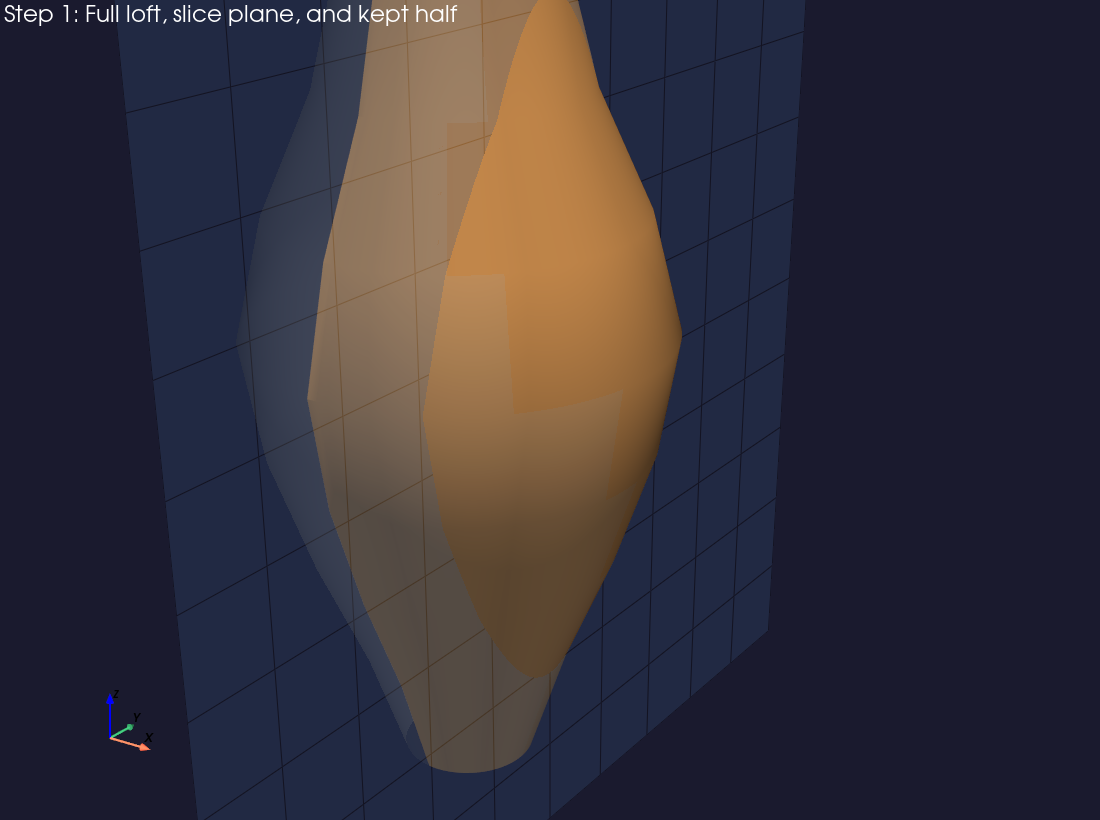

In [18]:
plane_size = 1.15 * max(
    full_surface.bounds[1] - full_surface.bounds[0],
    full_surface.bounds[3] - full_surface.bounds[2],
    full_surface.bounds[5] - full_surface.bounds[4],
)
slice_plane = pv.Plane(
    center=half_surface.center,
    direction=active_surface_config.slice_normal,
    i_size=plane_size,
    j_size=plane_size,
)

show_step(
    "Step 1: Loft the circles and clip the shape in half",
    "The eight circular sections are connected into one lofted skin. The blue plane is the YZ slicing plane at x = 0, and the solid orange surface is the kept half. This clip removes the mirrored side so the later Voronoi intersections are easier to interpret and do not duplicate across both halves.",
)
display_static_scene(
    title="Step 1: Full loft, slice plane, and kept half",
    bounds=full_surface.bounds,
    target=half_surface.center,
    meshes=[
        (
            full_surface,
            {
                "color": "#d9d9d9",
                "opacity": 0.18,
                "smooth_shading": True,
            },
        ),
        (
            slice_plane,
            {
                "color": "#6aa9ff",
                "opacity": 0.25,
                "show_edges": True,
            },
        ),
        (
            half_surface,
            {
                "color": "#ffb366",
                "opacity": 1.0,
                "smooth_shading": True,
            },
        ),
    ],
)


### Step 2: Seed the padded box for the bounded Voronoi construction

The cyan box is slightly larger than the kept loft half, and the yellow points are the random Voronoi seeds inside it. The padding matters because an unconstrained 3D Voronoi diagram would create infinite cells; this box forces every cell to stay finite before we intersect it with the loft.

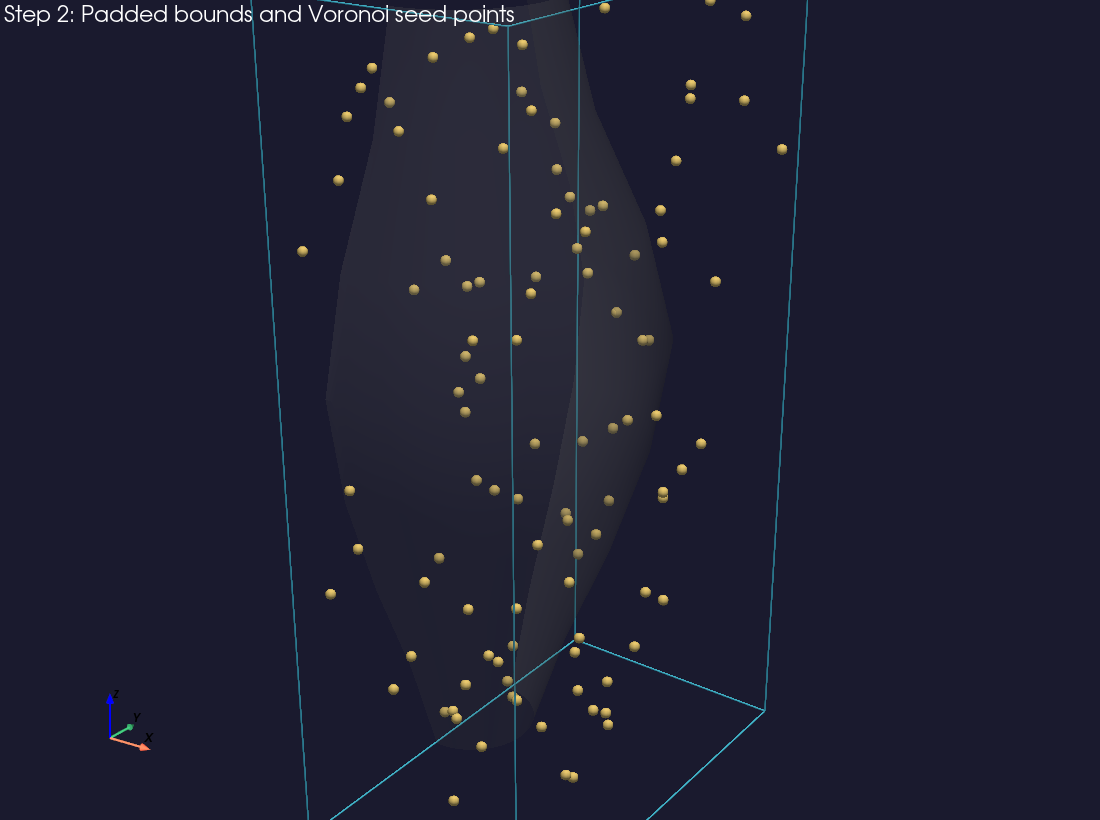

In [19]:
padded_box_edges = pv.Box(bounds=padded_bounds).extract_all_edges()

show_step(
    "Step 2: Seed the padded box for the bounded Voronoi construction",
    "The cyan box is slightly larger than the kept loft half, and the yellow points are the random Voronoi seeds inside it. The padding matters because an unconstrained 3D Voronoi diagram would create infinite cells; this box forces every cell to stay finite before we intersect it with the loft.",
)
display_static_scene(
    title="Step 2: Padded bounds and Voronoi seed points",
    bounds=padded_bounds,
    target=half_surface.center,
    meshes=[
        (
            half_surface,
            {
                "color": "#8c8c8c",
                "opacity": 0.22,
                "smooth_shading": True,
            },
        ),
    ],
    line_meshes=[
        (
            padded_box_edges,
            {
                "color": "#4dd7ff",
                "line_width": 2,
                "opacity": 0.95,
            },
        ),
    ],
    point_sets=[
        (
            seed_points,
            {
                "color": "#ffe082",
                "point_size": 11,
                "render_points_as_spheres": True,
                "opacity": 1.0,
            },
        ),
    ],
)


### Step 3: View every rebuilt intersection polyline as a separate colored trace

Each colored polyline is rebuilt from the detected discontinuity points of one retained intersection curve. Close vertices from neighboring cells are snapped together before anything downstream uses these polylines, which helps the later surface mesh stay closed without tiny breaks.

Raw intersection loops: 61
Retained intersection loops after neighbor filter: 60
Rebuilt line polylines used downstream: 60
Discarded isolated loops: 1


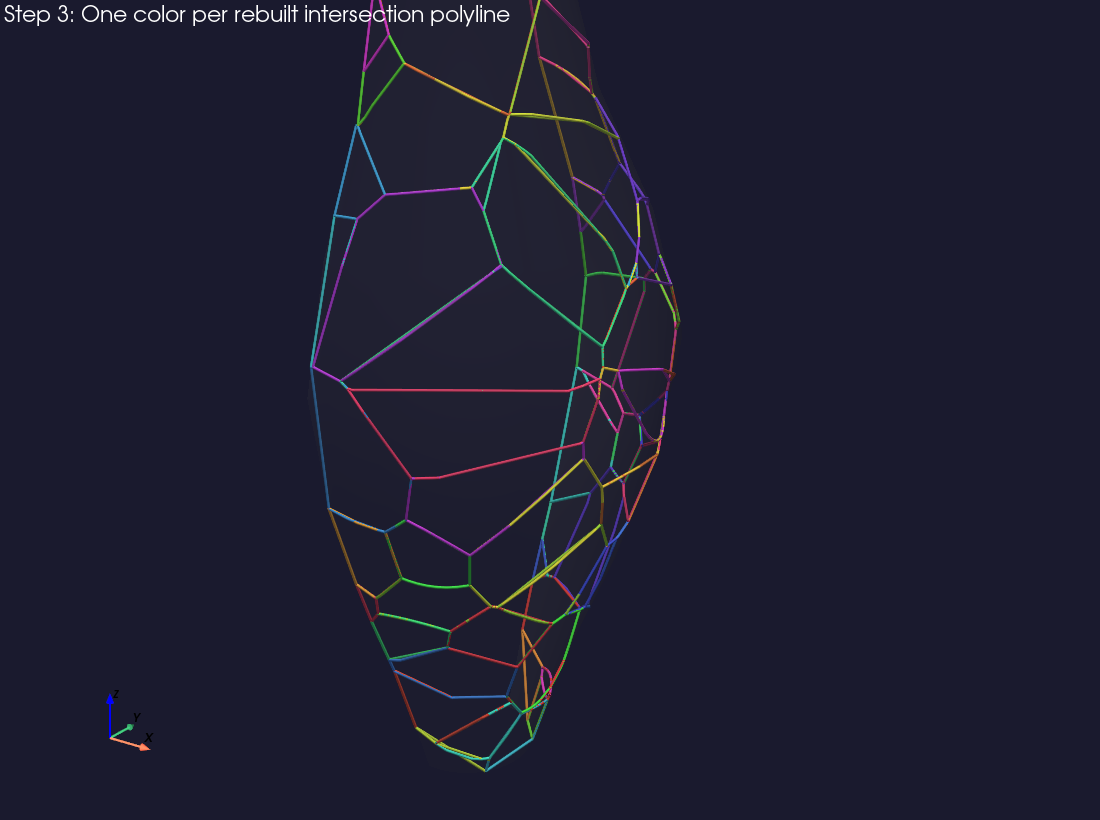

### Step 3A: Interactive inspection of the rebuilt intersection polylines

This opens the rebuilt and snapped intersection polylines in a native PyVista window so you can orbit, pan, and zoom around the clipped loft while checking how the downstream working curves sit on the surface.

In [20]:
show_step(
    "Step 3: View every rebuilt intersection polyline as a separate colored trace",
    "Each colored polyline is rebuilt from the detected discontinuity points of one retained intersection curve. Close vertices from neighboring cells are snapped together before anything downstream uses these polylines, which helps the later surface mesh stay closed without tiny breaks.",
)
print(f"Raw intersection loops: {len(raw_closed_polylines)}")
print(f"Retained intersection loops after neighbor filter: {retained_intersection_polyline_count}")
print(f"Rebuilt line polylines used downstream: {len(analysis_original_polylines)}")
print(f"Discarded isolated loops: {len(discarded_polyline_indices)}")
display_static_scene(
    title="Step 3: One color per rebuilt intersection polyline",
    bounds=half_surface.bounds,
    target=half_surface.center,
    meshes=[
        (
            half_surface,
            {
                "color": "#727272",
                "opacity": 0.13,
                "smooth_shading": True,
            },
        ),
    ],
    line_meshes=[
        (
            build_polyline_mesh([polyline]),
            {
                "color": curve_colors[index],
                "line_width": 3,
                "opacity": 1.0,
            },
        )
        for index, polyline in enumerate(analysis_original_polylines)
    ],
)
show_step(
    "Step 3A: Interactive inspection of the rebuilt intersection polylines",
    "This opens the rebuilt and snapped intersection polylines in a native PyVista window so you can orbit, pan, and zoom around the clipped loft while checking how the downstream working curves sit on the surface.",
)
display_interactive_scene(
    title="Step 3A: Interactive rebuilt intersection polylines",
    bounds=half_surface.bounds,
    target=half_surface.center,
    meshes=[
        (
            half_surface,
            {
                "color": "#727272",
                "opacity": 0.13,
                "smooth_shading": True,
            },
        ),
    ],
    line_meshes=[
        (
            build_polyline_mesh([polyline]),
            {
                "color": curve_colors[index],
                "line_width": 3,
                "opacity": 1.0,
            },
        )
        for index, polyline in enumerate(analysis_original_polylines)
    ],
    zoom_factor=1.15,
    window_size=(1300, 950),
)


In [21]:
show_step(
    "Step 4B: Interactive cell inspector (curve / surface / naked edges)",
    "Pick any cell by index. Three interactive windows open side by side: the polyline curve, the output surface mesh, and its naked boundary edges. All three are rotatable and zoomable. The cell label stays visible in each window title.",
)

cell_inspector_slider_row, cell_inspector_slider, _ = make_int_control(
    value=1,
    min_value=1,
    max_value=len(analysis_followup_polylines),
    step=1,
    description="Cell",
    slider_width="340px",
    input_width="90px",
)
cell_inspector_show_all = widgets.Checkbox(
    value=False,
    description="Show all cells from 0 to selected",
)
cell_inspector_summary = widgets.HTML()
cell_inspector_report = widgets.HTML(layout=widgets.Layout(max_height="280px", overflow="auto"))
cell_inspector_open = widgets.Button(
    description="Open interactive cell views",
    button_style="success",
)
cell_inspector_output = widgets.Output()

from compass_web.lofted_surface_voronoi import _fit_plane


def _cell_inspector_indices() -> list[int]:
    val = int(cell_inspector_slider.value)
    if val <= 0:
        return []
    if cell_inspector_show_all.value:
        return list(range(min(val, len(analysis_followup_polylines))))
    return [min(val, len(analysis_followup_polylines)) - 1]


def _cell_diagnostic(idx: int) -> dict:
    from collections import defaultdict as _dd
    a = curve_result.analyses[idx]
    mesh = analysis_output_meshes[idx]
    mode = analysis_output_modes[idx]
    if mesh.n_cells == 0:
        return {"idx": idx, "mode": mode, "empty": True}
    surf = extract_surface_mesh(mesh)
    pts = np.asarray(surf.points, dtype=float)
    fraw = np.asarray(surf.faces, dtype=int)
    fv = []
    c = 0
    while c < len(fraw):
        n = int(fraw[c])
        if n == 3:
            fv.append((int(fraw[c+1]), int(fraw[c+2]), int(fraw[c+3])))
        c += n + 1
    norms = []
    areas = []
    for aa, bb, cc in fv:
        e1 = pts[bb] - pts[aa]; e2 = pts[cc] - pts[aa]; nn = np.cross(e1, e2)
        nl = float(np.linalg.norm(nn))
        norms.append(nn / nl if nl > 1e-12 else np.zeros(3))
        areas.append(float(nl) * 0.5)
    etf = _dd(list)
    for fi, (aa, bb, cc) in enumerate(fv):
        for e in [(min(aa,bb),max(aa,bb)),(min(bb,cc),max(bb,cc)),(min(aa,cc),max(aa,cc))]:
            etf[e].append(fi)
    be = sum(1 for fis in etf.values() if len(fis) == 1)
    me = sum(1 for fis in etf.values() if len(fis) == 2)
    nm = sum(1 for fis in etf.values() if len(fis) > 2)
    bad = sum(1 for e, fis in etf.items() if len(fis) == 2 and float(np.dot(norms[fis[0]], norms[fis[1]])) < 0)
    dp = a.discontinuity_points
    if len(dp) >= 3:
        _, pu, pv_vec, pn = _fit_plane(dp)
        centered = dp - dp.mean(axis=0)
        oop = float(np.abs(centered @ pn).max())
        u_p = centered @ pu; v_p = centered @ pv_vec
        ips = float(np.sqrt((u_p.max()-u_p.min())**2 + (v_p.max()-v_p.min())**2))
        pr = oop / max(ips, 1e-9)
        ctr = a.circle_center; cd = dp - ctr
        ang = np.degrees(np.arctan2(cd @ pv_vec, cd @ pu))
        sa = np.sort(ang)
        gaps = np.diff(sa)
        wg = 360 - (sa[-1] - sa[0]) if len(sa) > 1 else 360.0
        mg = float(max(np.max(gaps), wg)) if len(gaps) > 0 else 360.0
    else:
        pr = 0.0; ips = 0.0; mg = 360.0
    return {
        "idx": idx, "mode": mode, "empty": False,
        "disc_pts": len(dp), "faces": surf.n_cells,
        "total_area": sum(areas), "boundary_edges": be,
        "manifold_edges": me, "nm_edges": nm,
        "bad_normals": bad, "planarity_ratio": pr,
        "max_angular_gap": mg, "bbox_volume": float(a.bbox_volume),
        "curve_length": float(a.curve_length),
        "circle_radius": float(a.circle_radius),
        "ratio": float(a.ratio),
        "extrusion_len": float(np.linalg.norm(a.extrusion_base_vector)),
    }


def update_cell_inspector_summary(*_: object) -> None:
    indices = _cell_inspector_indices()
    if not indices:
        cell_inspector_summary.value = "<b>No cell selected.</b>"
        cell_inspector_report.value = ""
        return
    diags = [_cell_diagnostic(idx) for idx in indices]
    issues = [d for d in diags if not d.get("empty") and d["bad_normals"] > 0]
    healthy = [d for d in diags if not d.get("empty") and d["bad_normals"] == 0]
    cell_inspector_summary.value = (
        f"<b>Showing {len(indices)} cell(s)</b>"
        f" | <span style='color:#ff5c5c'><b>{len(issues)} with normal issues</b></span>"
        f" | <span style='color:#4caf50'><b>{len(healthy)} healthy</b></span>"
    )
    rows = []
    for d in diags:
        if d.get("empty"):
            rows.append(f"<tr style='color:#888'><td>{d['idx']}</td><td>{d['mode']}</td><td colspan='12'>empty</td></tr>")
            continue
        color = "#ff5c5c" if d["bad_normals"] > 0 else "#ccc"
        rows.append(
            f"<tr style='color:{color}'>"
            f"<td><b>{d['idx']}</b></td>"
            f"<td>{d['mode']}</td>"
            f"<td>{d['disc_pts']}</td>"
            f"<td>{d['faces']}</td>"
            f"<td>{d['boundary_edges']}</td>"
            f"<td>{d['manifold_edges']}</td>"
            f"<td>{d['nm_edges']}</td>"
            f"<td><b>{d['bad_normals']}</b></td>"
            f"<td>{d['planarity_ratio']:.4f}</td>"
            f"<td>{d['max_angular_gap']:.0f}</td>"
            f"<td>{d['total_area']:.1f}</td>"
            f"<td>{d['bbox_volume']:.2f}</td>"
            f"<td>{d['curve_length']:.1f}</td>"
            f"<td>{d['ratio']:.3f}</td>"
            f"</tr>"
        )
    header = (
        "<tr style='color:#aaa;font-size:11px'>"
        "<th>ID</th><th>Class</th><th>Disc</th><th>Faces</th>"
        "<th>BE</th><th>ME</th><th>NM</th><th>BadN</th>"
        "<th>Planarity</th><th>Gap</th><th>Area</th>"
        "<th>BBoxVol</th><th>CrvLen</th><th>Ratio</th>"
        "</tr>"
    )
    cell_inspector_report.value = f"<table style='font-size:12px;border-collapse:collapse'>{header}{''.join(rows)}</table>"


for _w in [cell_inspector_slider, cell_inspector_show_all]:
    _w.observe(update_cell_inspector_summary, names="value")
update_cell_inspector_summary()


def open_cell_inspector_views(_: widgets.Button) -> None:
    indices = _cell_inspector_indices()
    if not indices:
        return

    all_polylines = []
    all_surfaces = []
    all_be_meshes = []
    all_nm_meshes = []
    all_disc_points = []
    bounds_candidates = []

    for idx in indices:
        polyline = analysis_followup_polylines[idx]
        mesh = analysis_output_meshes[idx]
        surf = extract_surface_mesh(mesh) if mesh.n_cells > 0 else pv.PolyData()
        surf = unify_mesh_normals(surf) if surf.n_cells > 0 else pv.PolyData()
        be = surf.extract_feature_edges(boundary_edges=True, feature_edges=False, manifold_edges=False, non_manifold_edges=False).clean() if surf.n_cells > 0 else pv.PolyData()
        nm = surf.extract_feature_edges(boundary_edges=False, feature_edges=False, manifold_edges=False, non_manifold_edges=True).clean() if surf.n_cells > 0 else pv.PolyData()
        all_polylines.append((idx, polyline))
        all_surfaces.append((idx, surf))
        all_be_meshes.append((idx, be))
        all_nm_meshes.append((idx, nm))
        if len(discontinuity_point_sets[idx]) > 0:
            all_disc_points.append((idx, discontinuity_point_sets[idx]))
        if mesh.n_points > 0:
            bounds_candidates.append(mesh.bounds)
        if len(polyline) > 0:
            pm = build_polyline_mesh([polyline])
            if pm.n_points > 0:
                bounds_candidates.append(pm.bounds)

    if not bounds_candidates:
        bounds_candidates.append(half_surface.bounds)
    view_bounds = padded_scene_bounds(merge_bounds(bounds_candidates), padding_fraction=0.12, min_padding=0.5)
    view_target = center_from_bounds(view_bounds)

    n_cells_shown = len(indices)
    last = indices[-1]
    title_tag = f"Cell {last} ({curve_labels[last]})" if n_cells_shown == 1 else f"Cells 0..{last} ({n_cells_shown} cells)"

    with cell_inspector_output:
        cell_inspector_output.clear_output(wait=True)
        display(Markdown(f"Opening three interactive views for **{title_tag}**."))

    plotter = pv.Plotter(
        notebook=False,
        shape=(1, 3),
        window_size=(1800, 700),
        title=title_tag,
    )
    plotter.set_background("#1a1a2e")

    plotter.subplot(0, 0)
    plotter.add_text(f"Curves: {title_tag}", font_size=11)
    plotter.add_mesh(half_surface, color="#727272", opacity=0.08, smooth_shading=True)
    for idx, polyline in all_polylines:
        if len(polyline) > 0:
            plotter.add_mesh(build_polyline_mesh([polyline]), color=curve_colors[idx], line_width=3 if n_cells_shown > 1 else 4, opacity=1.0)
    for idx, pts in all_disc_points:
        plotter.add_points(pts, color="#ff4d4d", point_size=8 if n_cells_shown > 1 else 10, render_points_as_spheres=True)
    plotter.camera_position = camera_position_from_bounds(view_bounds, view_target)
    plotter.camera.zoom(1.2)
    plotter.add_axes()

    plotter.subplot(0, 1)
    total_faces = sum(s.n_cells for _, s in all_surfaces)
    plotter.add_text(f"Surfaces: {title_tag} ({total_faces} faces)", font_size=11)
    plotter.add_mesh(half_surface, color="#727272", opacity=0.08, smooth_shading=True)
    label_points_list = []
    label_texts_list = []
    for idx, surf in all_surfaces:
        if surf.n_cells > 0:
            plotter.add_mesh(surf, color=curve_colors[idx], opacity=1.0, smooth_shading=True, show_edges=True, edge_color="#333333")
            label_points_list.append(np.asarray(surf.center, dtype=float))
            label_texts_list.append(str(idx))
    if label_points_list:
        label_pts_array = np.array(label_points_list, dtype=float)
        plotter.add_point_labels(
            label_pts_array,
            label_texts_list,
            shape_opacity=0.35,
            fill_shape=True,
            font_size=18,
            text_color="white",
            point_color="#ffe082",
            margin=5,
            show_points=True,
            point_size=8,
            always_visible=True,
        )
    plotter.camera_position = camera_position_from_bounds(view_bounds, view_target)
    plotter.camera.zoom(1.2)
    plotter.add_axes()

    plotter.subplot(0, 2)
    total_be = sum(b.n_cells for _, b in all_be_meshes)
    total_nm = sum(n.n_cells for _, n in all_nm_meshes)
    plotter.add_text(f"Naked edges: {title_tag} ({total_be} boundary, {total_nm} nm)", font_size=11)
    plotter.add_mesh(half_surface, color="#727272", opacity=0.08, smooth_shading=True)
    for idx, surf in all_surfaces:
        if surf.n_cells > 0:
            plotter.add_mesh(surf, color=curve_colors[idx], opacity=0.15, smooth_shading=True)
    for idx, be in all_be_meshes:
        if be.n_cells > 0:
            plotter.add_mesh(be, color="#00e5ff", line_width=4 if n_cells_shown > 1 else 5, opacity=1.0)
    for idx, nm in all_nm_meshes:
        if nm.n_cells > 0:
            plotter.add_mesh(nm, color="#ff3b30", line_width=3 if n_cells_shown > 1 else 4, opacity=0.9)
    plotter.camera_position = camera_position_from_bounds(view_bounds, view_target)
    plotter.camera.zoom(1.2)
    plotter.add_axes()

    plotter.link_views()
    plotter.show()


cell_inspector_open.on_click(open_cell_inspector_views)
display(
    widgets.VBox([
        cell_inspector_slider_row,
        cell_inspector_show_all,
        cell_inspector_summary,
        cell_inspector_report,
        cell_inspector_open,
        cell_inspector_output,
    ])
)

### Step 4B: Interactive cell inspector (curve / surface / naked edges)

Pick any cell by index. Three interactive windows open side by side: the polyline curve, the output surface mesh, and its naked boundary edges. All three are rotatable and zoomable. The cell label stays visible in each window title.

### Step 5: Build per-cell solids

Each cell patch is individually scaled (same center, non-uniform XY), its open edges lofted to form walls. Faces at the cutting plane (x=0) are offset by -2 units on X to prevent thin-wall artifacts. Each cell is closed into a watertight solid. Small degenerate cells (area < 5 or < 6 faces) are removed.

Cell patches kept: 60, removed (no edges): 0
Removed (small area/faces): 0
Removed (disconnected): 0
Cell solids closed: 60/60
Total assembly faces: 9790


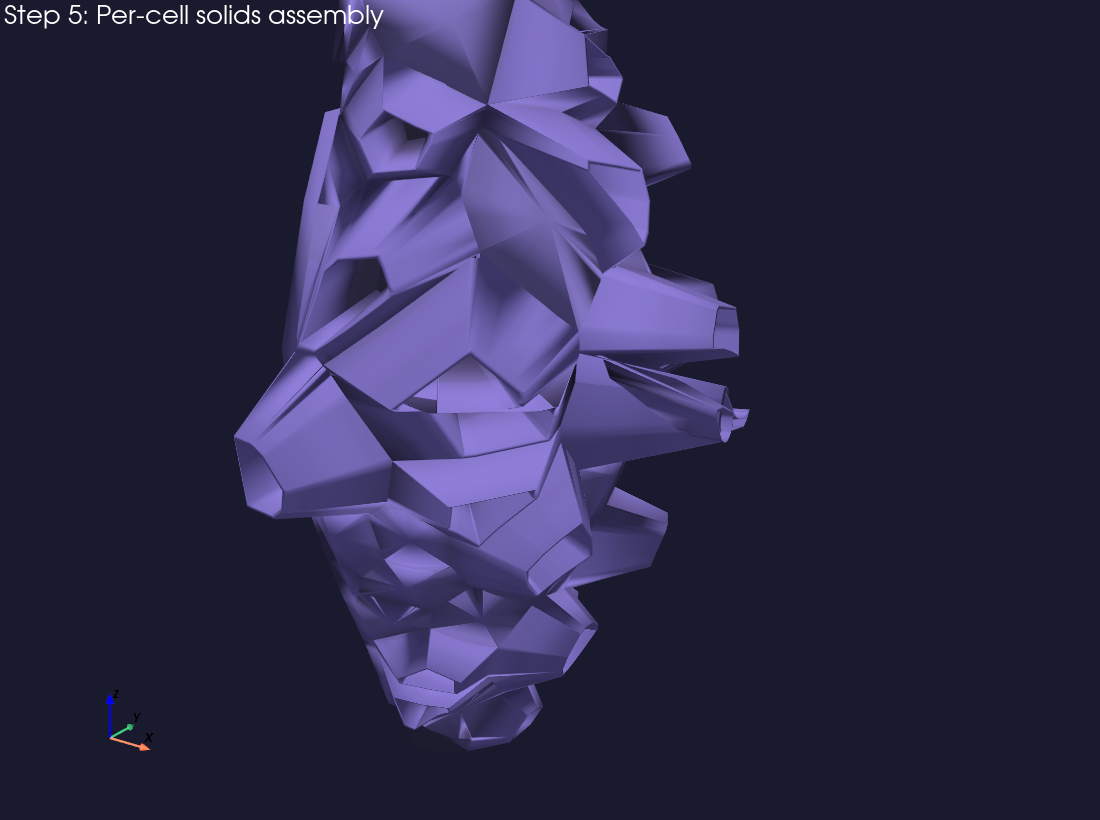

In [22]:
mesh_cleanup = clean_meshes_without_naked_edges(
    analysis_output_meshes,
    tolerance=active_surface_config.line_tolerance,
)
cell_patches = list(mesh_cleanup.kept_meshes)
removed_output_mesh_indices = list(mesh_cleanup.removed_indices)

cell_solids: list[pv.PolyData] = []
cell_solid_reports: list[dict] = []
cell_debug: list[dict] = []
for ci, cell_mesh in enumerate(cell_patches):
    surf = extract_surface_mesh(cell_mesh)
    scaled_surf = scale_polydata_in_xy(surf, center=initial_loft_bbox_center, scale_x=scale_x, scale_y=scale_y)
    _, open_edge_loops = extract_naked_edge_loops(surf, tolerance=active_surface_config.line_tolerance)
    scaled_loops = [
        scale_points_in_xy(loop, center=initial_loft_bbox_center, scale_x=scale_x, scale_y=scale_y)
        for loop in open_edge_loops
    ]
    loft_bands = [
        _loft_between_polylines(src_loop, tgt_loop)
        for src_loop, tgt_loop in zip(open_edge_loops, scaled_loops)
        if len(src_loop) >= 2 and len(tgt_loop) >= 2
    ]
    raw_solid = _merge_meshes([p for p in [surf, scaled_surf] + loft_bands if p.n_cells > 0])

    body_patch, moved_patch = split_and_offset_plane_faces(
        raw_solid,
        plane_normal=active_surface_config.slice_normal,
        plane_origin=active_surface_config.slice_origin,
        offset_amount=-2.0,
        tolerance=active_surface_config.line_tolerance,
    )

    if moved_patch.n_cells > 0:
        _, body_loops = extract_naked_edge_loops(body_patch, tolerance=active_surface_config.line_tolerance)
        _, moved_loops = extract_naked_edge_loops(moved_patch, tolerance=active_surface_config.line_tolerance)
        wall_lofts = []
        used_m: set[int] = set()
        for bl in body_loops:
            best_mi: int | None = None
            best_d = float("inf")
            for mi, ml in enumerate(moved_loops):
                if mi in used_m:
                    continue
                d = float(np.linalg.norm(bl.mean(axis=0) - ml.mean(axis=0)))
                if d < best_d:
                    best_d = d
                    best_mi = mi
            if best_mi is not None and len(bl) >= 2:
                used_m.add(best_mi)
                loft_result = align_loops_and_loft(bl, moved_loops[best_mi], tolerance=active_surface_config.line_tolerance)
                if loft_result.n_cells > 0:
                    wall_lofts.append(loft_result)
        solid = _merge_meshes([p for p in [body_patch, moved_patch] + wall_lofts if p.n_cells > 0])
        cell_debug.append({
            "idx": ci, "body_loops": len(body_loops), "moved_loops": len(moved_loops),
            "wall_lofts": len(wall_lofts), "plane_faces": moved_patch.n_cells,
        })
    else:
        solid = raw_solid
        cell_debug.append({"idx": ci, "body_loops": 0, "moved_loops": 0, "wall_lofts": 0, "plane_faces": 0})

    solid = close_mesh_boundaries(solid, tolerance=active_surface_config.line_tolerance)
    solid = unify_mesh_normals(solid)
    for _k in list(solid.cell_data.keys()):
        del solid.cell_data[_k]
    r = build_mesh_printability_report(solid, tolerance=active_surface_config.line_tolerance)
    cell_solids.append(solid)
    cell_solid_reports.append({"idx": ci, "faces": solid.n_cells, "closed": r.is_closed, "be": r.boundary_edge_count})

# Filter: remove disconnected cells (not in the largest connected region)
test_assembly = _merge_meshes([s for s in cell_solids if s.n_cells > 0])
n_regions = count_connected_regions(test_assembly)
if n_regions > 1:
    conn = test_assembly.connectivity()
    region_ids = np.asarray(conn["RegionId"], dtype=int)
    from collections import Counter as _Counter
    region_sizes = _Counter(region_ids)
    largest_rid = max(region_sizes, key=region_sizes.get)
    face_offset = 0
    keep_mask = []
    for ci, solid in enumerate(cell_solids):
        if solid.n_cells == 0:
            keep_mask.append(False)
            continue
        mid = face_offset + solid.n_cells // 2
        in_main = int(region_ids[mid]) == largest_rid if mid < len(region_ids) else False
        keep_mask.append(in_main)
        face_offset += solid.n_cells
    removed_disconnected = sum(1 for k in keep_mask if not k)
    cell_solids = [s for s, k in zip(cell_solids, keep_mask) if k]
    cell_solid_reports = [r for r, k in zip(cell_solid_reports, keep_mask) if k]
    cell_debug = [d for d, k in zip(cell_debug, keep_mask) if k]
else:
    removed_disconnected = 0

closed_count = sum(1 for r in cell_solid_reports if r["closed"])
generated_surface = _merge_meshes([s for s in cell_solids if s.n_cells > 0])

generated_bounds = generated_surface.bounds if generated_surface.n_points else half_surface.bounds
generated_target = generated_surface.center if generated_surface.n_points else half_surface.center

show_step(
    "Step 5: Build per-cell solids",
    "Each cell patch is individually scaled (same center, non-uniform XY), its open edges lofted to form walls. "
    "Faces at the cutting plane (x=0) are offset by -2 units on X to prevent thin-wall artifacts. "
    "Each cell is closed into a watertight solid. Small degenerate cells (area < 5 or < 6 faces) are removed.",
)
print(f"Cell patches kept: {len(cell_patches)}, removed (no edges): {len(removed_output_mesh_indices)}")
print(f"Removed (small area/faces): {len(cell_patches) - len(cell_solids) - removed_disconnected}")
print(f"Removed (disconnected): {removed_disconnected}")
print(f"Cell solids closed: {closed_count}/{len(cell_solids)}")
print(f"Total assembly faces: {generated_surface.n_cells}")
display_static_scene(
    title="Step 5: Per-cell solids assembly",
    bounds=generated_bounds,
    target=generated_target,
    meshes=[
        (half_surface, {"color": "#808080", "opacity": 0.1, "smooth_shading": True}),
        (generated_surface, {"color": "#9b8cff", "opacity": 1.0, "smooth_shading": True}),
    ],
)
display_interactive_scene(
    title="Step 5A: Interactive per-cell solids assembly",
    bounds=generated_bounds,
    target=generated_target,
    meshes=[
        (half_surface, {"color": "#808080", "opacity": 0.08, "smooth_shading": True}),
        (generated_surface, {"color": "#9b8cff", "opacity": 1.0, "smooth_shading": True}),
    ],
    zoom_factor=1.2,
    window_size=(1300, 950),
)


In [23]:
show_step(
    "Step 5B: Per-cell solid inspector",
    "Use the slider to pick a cell. With the checkbox off, you see that single cell solid. With it on, you see all solids from 0 up to the selected index. Click the button to open an interactive view.",
)

cell_solid_slider_row, cell_solid_slider, _ = make_int_control(
    value=1, min_value=1, max_value=len(cell_solids),
    step=1, description="Cell", slider_width="340px", input_width="90px",
)
cell_solid_show_all = widgets.Checkbox(value=False, description="Show all up to selected")
cell_solid_summary = widgets.HTML()
cell_solid_open = widgets.Button(description="Open interactive view", button_style="success")
cell_solid_output = widgets.Output()


def _cell_solid_indices() -> list[int]:
    val = int(cell_solid_slider.value)
    if val <= 0:
        return []
    if cell_solid_show_all.value:
        return list(range(min(val, len(cell_solids))))
    return [min(val, len(cell_solids)) - 1]


def _update_cell_solid_summary(*_: object) -> None:
    indices = _cell_solid_indices()
    if not indices:
        cell_solid_summary.value = "<b>No cell selected.</b>"
        return
    total_f = sum(cell_solids[i].n_cells for i in indices)
    closed_n = sum(1 for i in indices if cell_solid_reports[i]["closed"])
    if len(indices) == 1:
        idx = indices[0]
        rpt = cell_solid_reports[idx]
        cell_solid_summary.value = (
            f"<b>Cell {idx}</b>"
            f" | Faces: {rpt['faces']}"
            f" | Closed: {rpt['closed']}"
            f" | BE: {rpt['be']}"
        )
    else:
        cell_solid_summary.value = (
            f"<b>Cells 0..{indices[-1]}</b> ({len(indices)} cells)"
            f" | Total faces: {total_f}"
            f" | Closed: {closed_n}/{len(indices)}"
        )


for _w in [cell_solid_slider, cell_solid_show_all]:
    _w.observe(_update_cell_solid_summary, names="value")
_update_cell_solid_summary()


def _open_cell_solid_view(_: widgets.Button) -> None:
    indices = _cell_solid_indices()
    if not indices:
        return
    n = len(indices)

    if n == 1:
        idx = indices[0]
        title = f"Cell {idx} debug"
        dbg = cell_debug[idx]
        solid = cell_solids[idx]
        color = curve_colors[mesh_cleanup.kept_indices[idx]]

        raw_mesh = extract_surface_mesh(cell_patches[idx])
        raw_scaled = scale_polydata_in_xy(raw_mesh, center=initial_loft_bbox_center, scale_x=scale_x, scale_y=scale_y)
        _, raw_loops = extract_naked_edge_loops(raw_mesh, tolerance=active_surface_config.line_tolerance)
        raw_scaled_loops = [scale_points_in_xy(l, center=initial_loft_bbox_center, scale_x=scale_x, scale_y=scale_y) for l in raw_loops]
        raw_lofts = [_loft_between_polylines(s, t) for s, t in zip(raw_loops, raw_scaled_loops) if len(s) >= 2 and len(t) >= 2]
        raw_solid = _merge_meshes([p for p in [raw_mesh, raw_scaled] + raw_lofts if p.n_cells > 0])

        body_patch, moved_patch = split_and_offset_plane_faces(
            raw_solid, plane_normal=active_surface_config.slice_normal,
            plane_origin=active_surface_config.slice_origin, offset_amount=-2.0,
            tolerance=active_surface_config.line_tolerance,
        )
        _, body_loops = extract_naked_edge_loops(body_patch, tolerance=active_surface_config.line_tolerance) if body_patch.n_cells > 0 else (None, [])
        _, moved_loops = extract_naked_edge_loops(moved_patch, tolerance=active_surface_config.line_tolerance) if moved_patch.n_cells > 0 else (None, [])
        body_edge_mesh = build_polyline_mesh(body_loops)
        moved_edge_mesh = build_polyline_mesh(moved_loops)

        bounds_list = [s.bounds for s in [solid, body_patch, moved_patch] if s.n_cells > 0]
        if not bounds_list:
            bounds_list = [half_surface.bounds]
        vb = padded_scene_bounds(merge_bounds(bounds_list), padding_fraction=0.15, min_padding=0.5)
        vt = center_from_bounds(vb)

        with cell_solid_output:
            cell_solid_output.clear_output(wait=True)
            display(Markdown(
                f"**Cell {idx}**: plane_faces={dbg['plane_faces']}, "
                f"body_loops={dbg['body_loops']}, moved_loops={dbg['moved_loops']}, "
                f"wall_lofts={dbg['wall_lofts']}"
            ))

        ncols = 4 if moved_patch.n_cells > 0 else 2
        plotter = pv.Plotter(notebook=False, shape=(1, ncols), window_size=(ncols * 450, 700), title=title)
        plotter.set_background("#1a1a2e")

        plotter.subplot(0, 0)
        plotter.add_text(f"Raw solid (before split)", font_size=10)
        plotter.add_mesh(raw_solid, color=color, opacity=1.0, smooth_shading=True, show_edges=True, edge_color="#333333")
        plotter.camera_position = camera_position_from_bounds(vb, vt)
        plotter.camera.zoom(1.2)
        plotter.add_axes()

        plotter.subplot(0, 1)
        plotter.add_text(f"Final solid ({solid.n_cells}f)", font_size=10)
        plotter.add_mesh(solid, color=color, opacity=1.0, smooth_shading=True, show_edges=True, edge_color="#333333")
        plotter.camera_position = camera_position_from_bounds(vb, vt)
        plotter.camera.zoom(1.2)
        plotter.add_axes()

        if ncols == 4:
            plotter.subplot(0, 2)
            plotter.add_text(f"Body ({body_patch.n_cells}f) + Moved ({moved_patch.n_cells}f)", font_size=10)
            if body_patch.n_cells > 0:
                plotter.add_mesh(body_patch, color="#72b7ff", opacity=0.7, smooth_shading=True)
            if moved_patch.n_cells > 0:
                plotter.add_mesh(moved_patch, color="#ff9f43", opacity=0.9, smooth_shading=True)
            plotter.camera_position = camera_position_from_bounds(vb, vt)
            plotter.camera.zoom(1.2)
            plotter.add_axes()

            plotter.subplot(0, 3)
            plotter.add_text(f"Open edges: body={len(body_loops)} moved={len(moved_loops)}", font_size=10)
            if body_patch.n_cells > 0:
                plotter.add_mesh(body_patch, color="#72b7ff", opacity=0.12, smooth_shading=True)
            if moved_patch.n_cells > 0:
                plotter.add_mesh(moved_patch, color="#ff9f43", opacity=0.12, smooth_shading=True)
            if body_edge_mesh.n_points > 0:
                plotter.add_mesh(body_edge_mesh, color="#00e5ff", line_width=5, opacity=1.0)
            if moved_edge_mesh.n_points > 0:
                plotter.add_mesh(moved_edge_mesh, color="#ff3b30", line_width=5, opacity=1.0)
            plotter.camera_position = camera_position_from_bounds(vb, vt)
            plotter.camera.zoom(1.2)
            plotter.add_axes()

        plotter.link_views()
        plotter.show()
    else:
        title = f"Cells 0..{indices[-1]} ({n})"
        bounds_list = [cell_solids[i].bounds for i in indices if cell_solids[i].n_cells > 0]
        if not bounds_list:
            bounds_list = [half_surface.bounds]
        vb = padded_scene_bounds(merge_bounds(bounds_list), padding_fraction=0.12, min_padding=0.5)
        vt = center_from_bounds(vb)
        with cell_solid_output:
            cell_solid_output.clear_output(wait=True)
            display(Markdown(f"Opening view for **{title}**."))
        plotter = pv.Plotter(notebook=False, window_size=(1400, 900), title=title)
        plotter.set_background("#1a1a2e")
        plotter.add_mesh(half_surface, color="#727272", opacity=0.06, smooth_shading=True)
        for idx in indices:
            plotter.add_mesh(cell_solids[idx], color=curve_colors[mesh_cleanup.kept_indices[idx]], opacity=1.0, smooth_shading=True)
        if n <= 30:
            lp = np.array([cell_solids[i].center for i in indices if cell_solids[i].n_cells > 0])
            lt = [str(i) for i in indices if cell_solids[i].n_cells > 0]
            if len(lp) > 0:
                plotter.add_point_labels(lp, lt, font_size=14, text_color="white", point_size=6, always_visible=True, shape_opacity=0.25)
        plotter.camera_position = camera_position_from_bounds(vb, vt)
        plotter.camera.zoom(1.3)
        plotter.add_axes()
        plotter.show()


cell_solid_open.on_click(_open_cell_solid_view)
display(widgets.VBox([
    cell_solid_slider_row,
    cell_solid_show_all,
    cell_solid_summary,
    cell_solid_open,
    cell_solid_output,
]))

### Step 5B: Per-cell solid inspector

Use the slider to pick a cell. With the checkbox off, you see that single cell solid. With it on, you see all solids from 0 up to the selected index. Click the button to open an interactive view.

In [24]:
show_step(
    "Step 6: Export per-cell volumes as STL",
    "Orients normals outward on each cell solid, fixes winding via trimesh, rotates so the sliced face lies flat on XY, and exports with a timestamped filename.",
)

import trimesh
from datetime import datetime


def build_export_trimesh(solids_list: list[pv.PolyData]) -> trimesh.Trimesh:
    cell_tms = []
    for solid in solids_list:
        solid_o = orient_normals_outward(solid)
        pts_s = np.asarray(solid_o.points, dtype=float)
        fraw_s = np.asarray(solid_o.faces, dtype=int)
        fv_s = []
        c_s = 0
        while c_s < len(fraw_s):
            n_s = int(fraw_s[c_s])
            if n_s == 3:
                fv_s.append([int(fraw_s[c_s + 1]), int(fraw_s[c_s + 2]), int(fraw_s[c_s + 3])])
            c_s += n_s + 1
        tm = trimesh.Trimesh(vertices=pts_s, faces=np.array(fv_s), process=True)
        trimesh.repair.fix_normals(tm)
        trimesh.repair.fix_winding(tm)
        cell_tms.append(tm)
    combined = trimesh.util.concatenate(cell_tms)
    trimesh.repair.fix_normals(combined, multibody=True)
    return combined


final_trimesh = build_export_trimesh(cell_solids)
volume_count = sum(
    1 for s in cell_solids
    if trimesh.Trimesh(
        vertices=np.asarray(orient_normals_outward(s).points),
        faces=np.asarray(orient_normals_outward(s).faces).reshape((-1, 4))[:, 1:] if orient_normals_outward(s).n_cells > 0 else np.zeros((0, 3), dtype=int),
        process=True,
    ).is_volume
)

# Rotate so the sliced face (originally at x=0, normal along X) lies flat on XY
# Rotate -90 degrees around Z so X axis becomes Y axis, putting the flat face on the ground
rot_matrix = trimesh.transformations.rotation_matrix(np.radians(-90), [0, 1, 0])
final_trimesh.apply_transform(rot_matrix)

print(
    f"Cell volumes: {volume_count}/{len(cell_solids)}, "
    f"combined faces: {len(final_trimesh.faces)}, "
    f"watertight: {final_trimesh.is_watertight}, "
    f"volume: {final_trimesh.is_volume}"
)

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
export_dir = Path("exports")
export_dir.mkdir(parents=True, exist_ok=True)
stl_path = export_dir / f"voronoi_shell_{ts}.stl"
final_trimesh.export(str(stl_path))
print(f"STL exported to: {stl_path} ({stl_path.stat().st_size / 1024:.1f} KB)")

display_interactive_scene(
    title="Step 6: Final assembly (per-cell volumes, rotated for printing)",
    bounds=generated_bounds,
    target=generated_target,
    meshes=[
        (generated_surface, {"color": "#9b8cff", "opacity": 1.0, "smooth_shading": True}),
    ],
    zoom_factor=1.8,
    window_size=(1300, 950),
)


### Step 6: Export per-cell volumes as STL

Orients normals outward on each cell solid, fixes winding via trimesh, rotates so the sliced face lies flat on XY, and exports with a timestamped filename.

Cell volumes: 22/60, combined faces: 9790, watertight: True, volume: True
STL exported to: exports\voronoi_shell_20260325_172143.stl (478.1 KB)


In [25]:
show_step(
    "Step 7: Auto-retry with different seeds",
    "If the exported mesh is not a valid volume, this cell automatically retries the full pipeline with different voronoi seeds (up to 10 attempts). Only the seed changes; all other parameters stay the same.",
)


def run_full_pipeline_with_seed(seed_value: int) -> tuple[trimesh.Trimesh, bool]:
    import vtk as _vtk
    _vtk.vtkObject.GlobalWarningDisplayOff()
    _pcfg = load_voronoi_point_config(point_config_path)
    from dataclasses import replace as _replace
    _pcfg = _replace(_pcfg, random_seed=seed_value)
    _sd = random_points_in_bounds(padded_bounds, _pcfg.seed_count, _pcfg.random_seed)
    _cl = build_bounded_voronoi_cells(_sd, padded_bounds)
    _rp = intersect_cells_with_surface(half_surface, _cl, active_surface_config.line_tolerance)
    _cp = rebuild_polylines_from_discontinuities(_rp, active_surface_config.line_tolerance)
    if not _cp:
        return trimesh.Trimesh(), False
    _cr = analyze_and_generate_surfaces(
        _cp, loft_bounds=full_surface.bounds,
        tolerance=active_surface_config.line_tolerance,
        extrusion_multiplier=extrusion_multiplier,
        small_cell_extrusion_factor=SMALL_CELL_EXTRUSION_FACTOR,
        extrusion_scale_origin=initial_loft_bbox_center,
        planar_scale_factors=(scale_x, scale_y),
        slice_plane_x=active_surface_config.slice_origin[0],
    )
    _ao = build_analysis_output_meshes(
        _cr.analyses, average_ratio=_cr.average_ratio,
        loft_bounds=full_surface.bounds,
        tolerance=active_surface_config.line_tolerance,
        extrusion_multiplier=extrusion_multiplier,
        small_cell_extrusion_factor=SMALL_CELL_EXTRUSION_FACTOR,
        slice_plane_x=active_surface_config.slice_origin[0],
    )
    _cu = clean_meshes_without_naked_edges(list(_ao.output_meshes), tolerance=active_surface_config.line_tolerance)
    _solids = []
    for _m in _cu.kept_meshes:
        _surf = extract_surface_mesh(_m)
        _area = float(_surf.area) if _surf.n_cells > 0 else 0
        if _area < 5 or _surf.n_cells < 6:
            continue
        _sc2 = scale_polydata_in_xy(_surf, center=initial_loft_bbox_center, scale_x=scale_x, scale_y=scale_y)
        _, _sl = extract_naked_edge_loops(_surf, tolerance=active_surface_config.line_tolerance)
        _ssl = [scale_points_in_xy(_l, center=initial_loft_bbox_center, scale_x=scale_x, scale_y=scale_y) for _l in _sl]
        _lb = [_loft_between_polylines(_s, _t) for _s, _t in zip(_sl, _ssl) if len(_s) >= 2 and len(_t) >= 2]
        _raw = _merge_meshes([_p for _p in [_surf, _sc2] + _lb if _p.n_cells > 0])
        _body, _moved = split_and_offset_plane_faces(
            _raw, plane_normal=active_surface_config.slice_normal,
            plane_origin=active_surface_config.slice_origin,
            offset_amount=-2.0, tolerance=active_surface_config.line_tolerance,
        )
        if _moved.n_cells > 0:
            _, _bl2 = extract_naked_edge_loops(_body, tolerance=active_surface_config.line_tolerance)
            _, _ml2 = extract_naked_edge_loops(_moved, tolerance=active_surface_config.line_tolerance)
            _wl = []
            _used = set()
            for _bl in _bl2:
                _bmi = None
                _bd = float("inf")
                for _mi, _ml in enumerate(_ml2):
                    if _mi in _used:
                        continue
                    _d = float(np.linalg.norm(_bl.mean(axis=0) - _ml.mean(axis=0)))
                    if _d < _bd:
                        _bd = _d
                        _bmi = _mi
                if _bmi is not None:
                    _used.add(_bmi)
                    _lr = align_loops_and_loft(_bl, _ml2[_bmi], tolerance=active_surface_config.line_tolerance)
                    if _lr.n_cells > 0:
                        _wl.append(_lr)
            _solid = _merge_meshes([_p for _p in [_body, _moved] + _wl if _p.n_cells > 0])
        else:
            _solid = _raw
        _solid = close_mesh_boundaries(_solid, tolerance=active_surface_config.line_tolerance)
        _solid = unify_mesh_normals(_solid)
        for _k in list(_solid.cell_data.keys()):
            del _solid.cell_data[_k]
        _solids.append(_solid)
    if not _solids:
        return trimesh.Trimesh(), False
    _result = build_export_trimesh(_solids)
    rot = trimesh.transformations.rotation_matrix(np.radians(-90), [0, 1, 0])
    _result.apply_transform(rot)
    return _result, _result.is_volume


if not final_trimesh.is_volume:
    print("Mesh is not a valid volume. Starting auto-retry with different seeds...")
    base_seed = int(seed_slider.value)
    for attempt in range(1, 11):
        new_seed = base_seed + attempt * 7
        print(f"  Attempt {attempt}/10 with seed {new_seed}...")
        retry_mesh, is_vol = run_full_pipeline_with_seed(new_seed)
        if is_vol:
            ts_retry = datetime.now().strftime("%Y%m%d_%H%M%S")
            retry_path = export_dir / f"voronoi_shell_{ts_retry}_seed{new_seed}.stl"
            retry_mesh.export(str(retry_path))
            print(f"  SUCCESS with seed {new_seed}: {len(retry_mesh.faces)}f, exported to {retry_path}")
            break
        else:
            print(f"  Seed {new_seed}: not a valid volume, trying next...")
    else:
        print("  All 10 attempts failed. Try adjusting other parameters.")
else:
    print("Mesh is already a valid volume. No retry needed.")

### Step 7: Auto-retry with different seeds

If the exported mesh is not a valid volume, this cell automatically retries the full pipeline with different voronoi seeds (up to 10 attempts). Only the seed changes; all other parameters stay the same.

Mesh is already a valid volume. No retry needed.
